# Asset position generation

In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import sys
sys.path.append("src/forest_gen")

from asset_dist import Simulation, Species, Plant, SimulationState


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Generate plot for generated coordinates with a grid

from typing import Iterable
from matplotlib import colormaps
CMAP = colormaps['viridis']

def plot_state(state: SimulationState, year: int):
    species = tuple(set(tree.species for tree in state))
    
    
    x_vals = [tree.coords[0] for tree in state]
    y_vals = [tree.coords[1] for tree in state]
    colors = [CMAP(species.index(tree.species) / len(species)) for tree in state]

    plt.figure(figsize=(8, 8))

    plt.scatter(x_vals, y_vals, c=colors, marker='o')

    plt.title(f"Tree Distribution at Year {year}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(0, state.size[0])
    plt.ylim(0, state.size[1])
    plt.grid(False)
    plt.show()

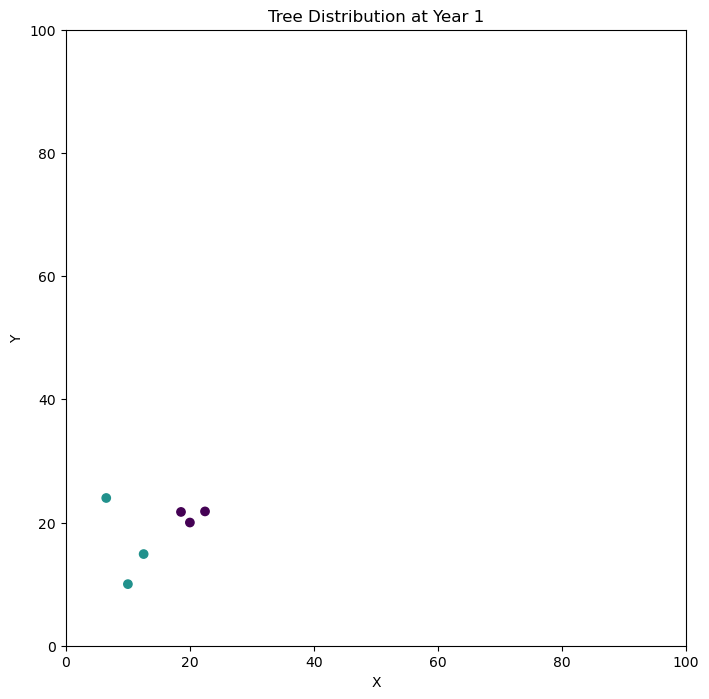

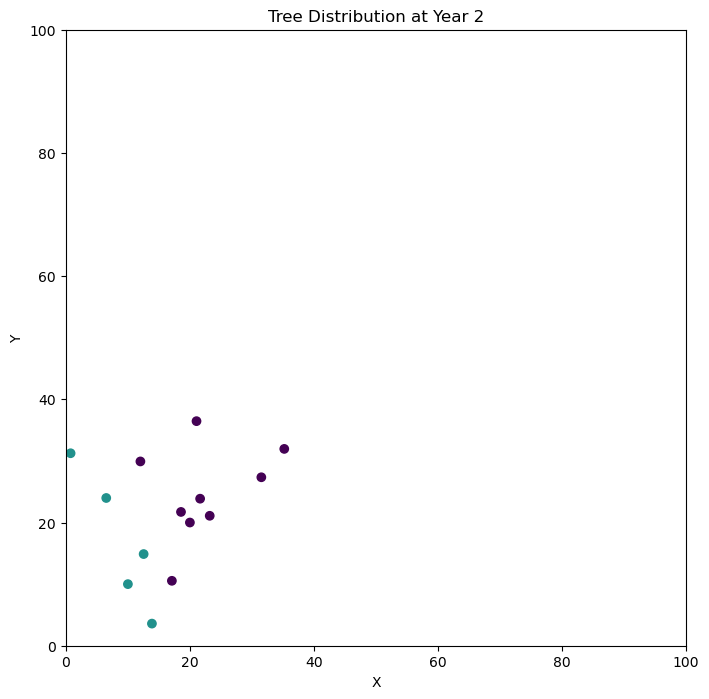

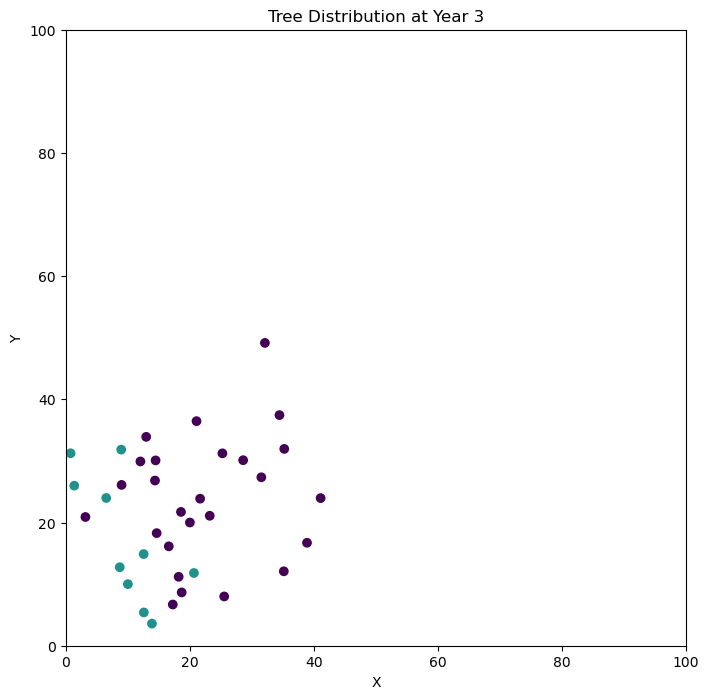

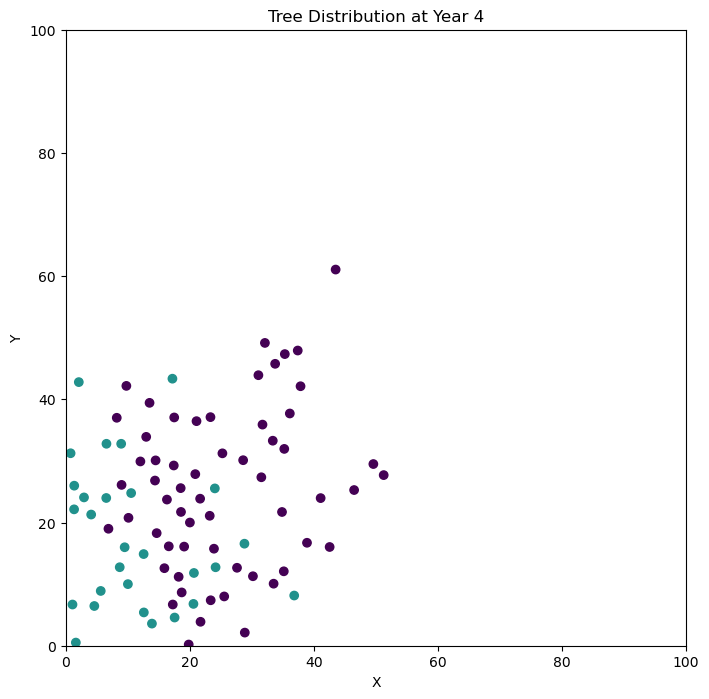

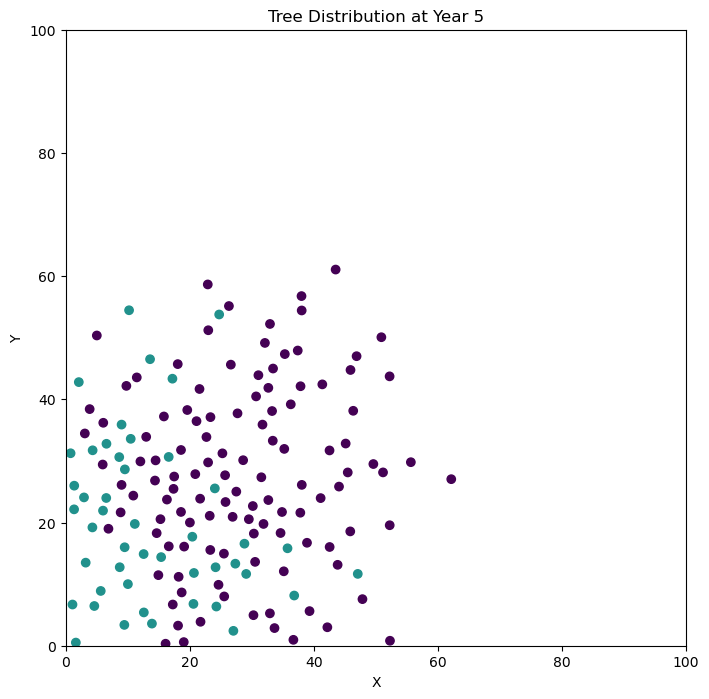

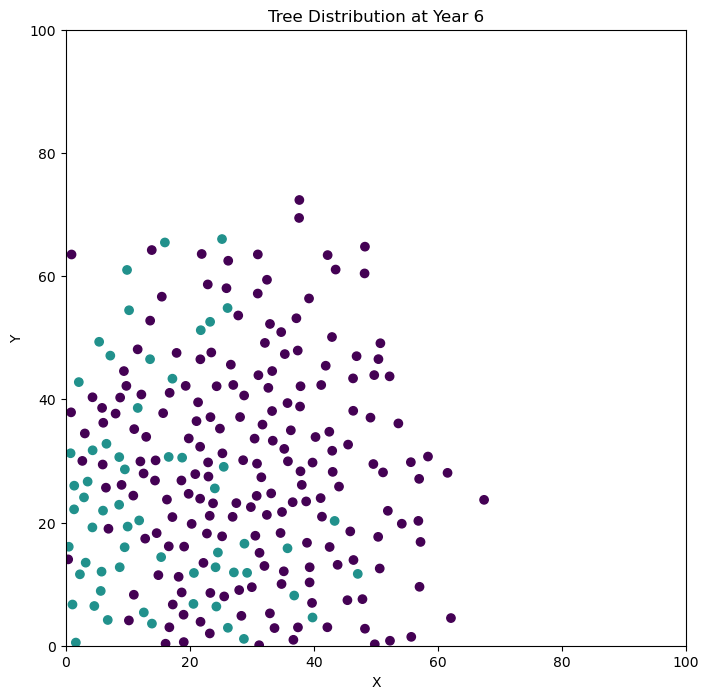

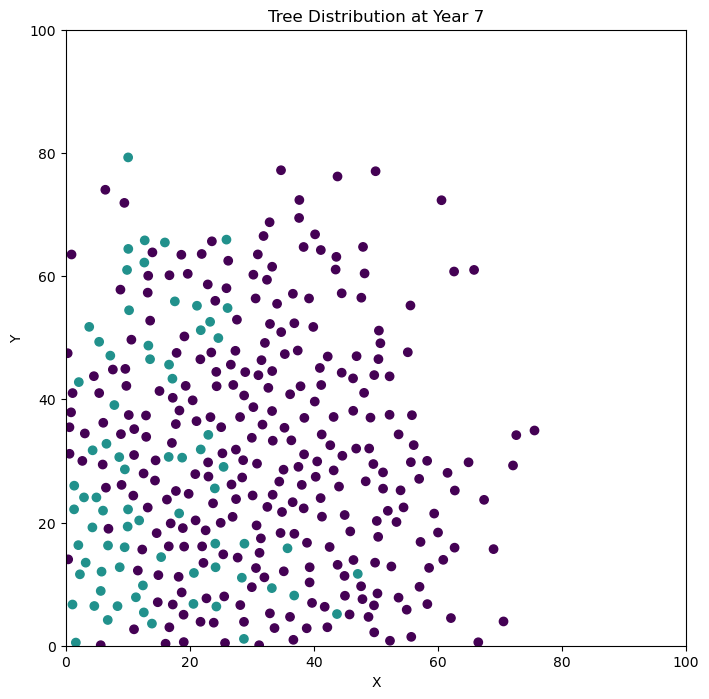

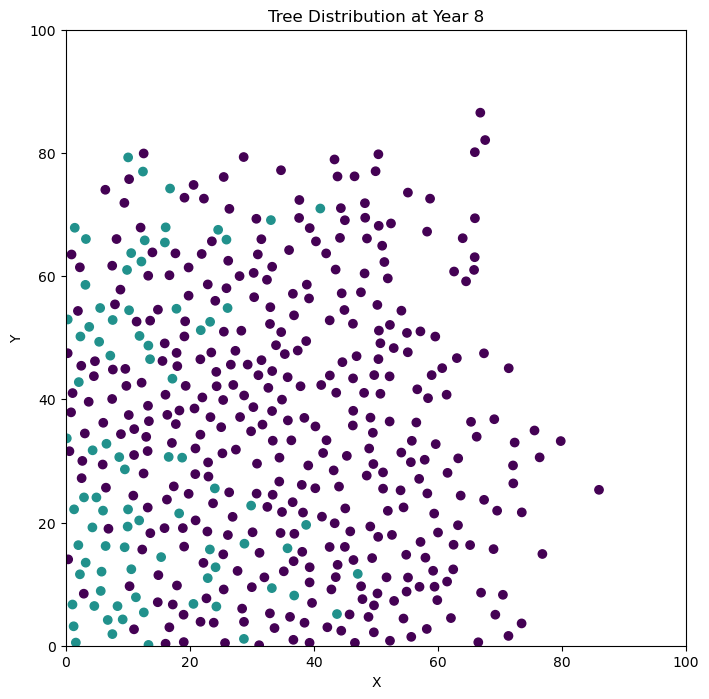

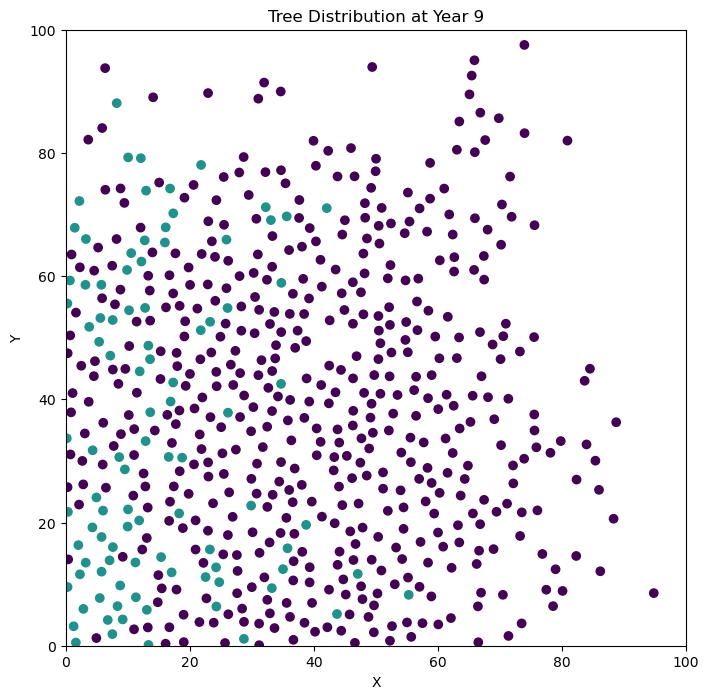

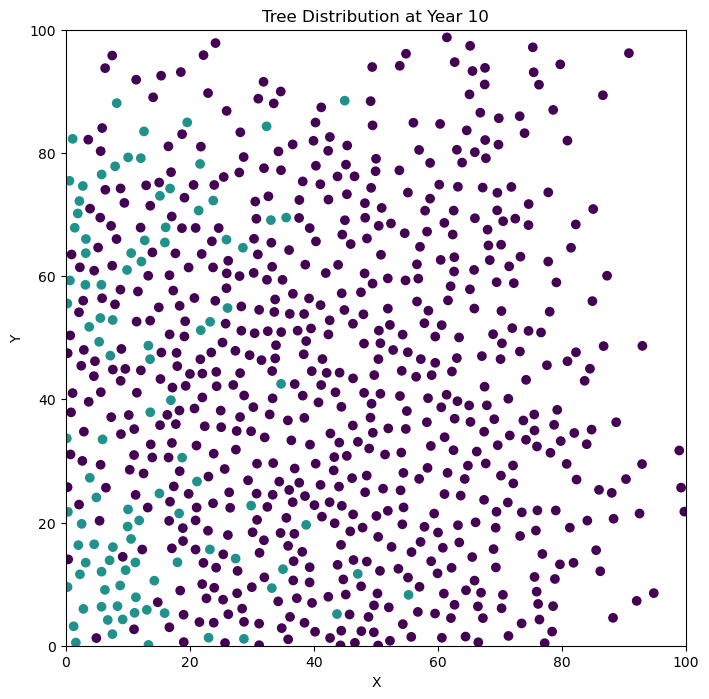

In [12]:

size = 100.0

RADIUS = 2.0

random_tree = Species("A tree", 5, 0.01, radius=RADIUS)
another_tree = Species("Another tree", 5, 0.02, radius=RADIUS)
bush = Species("Bush", 5, 0.01, radius=RADIUS)

sim = Simulation((size, size), {"tree":{random_tree, another_tree}, "bush":{bush}})
state = SimulationState([Plant((size / 10, size / 10), random_tree, 0), Plant((size / 5, size / 5), another_tree, 0)], (size, size))
for i in range(10):
    state.run_state(1)
    plot_state(state, i + 1)

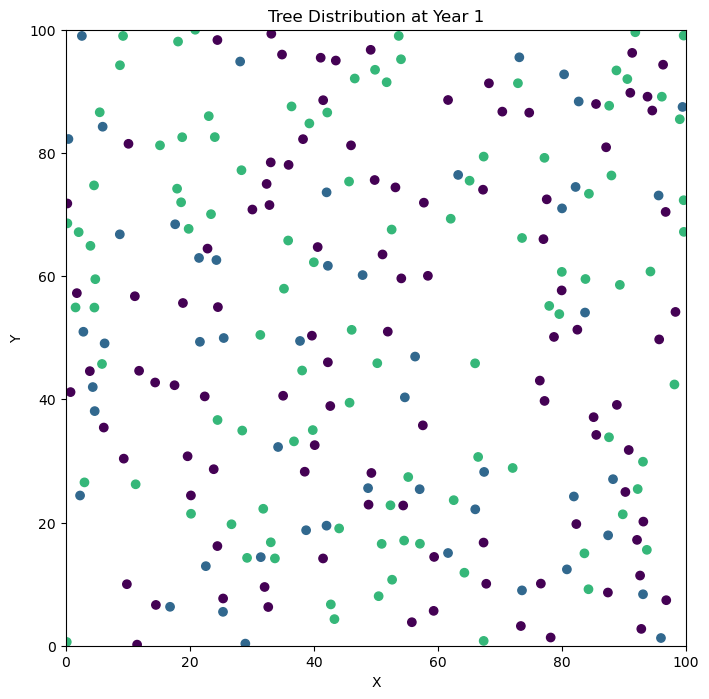

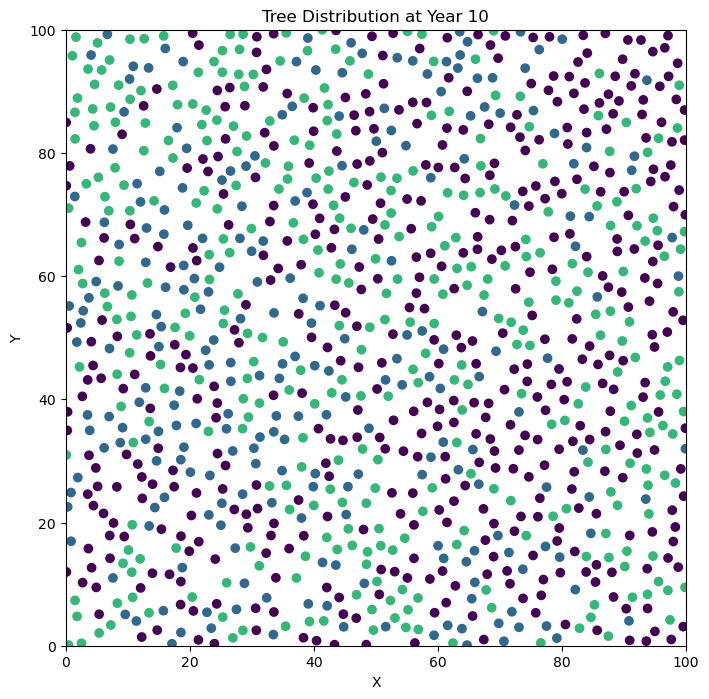

In [13]:
state = sim.new_state(1.0)
plot_state(state, 1)
state.run_state(10)
plot_state(state, 10)